In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
print(X.shape)
print(X.isnull().sum())
print(y.value_counts())

(569, 30)
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64
1    357
0    212
Name: count, dtype: int64


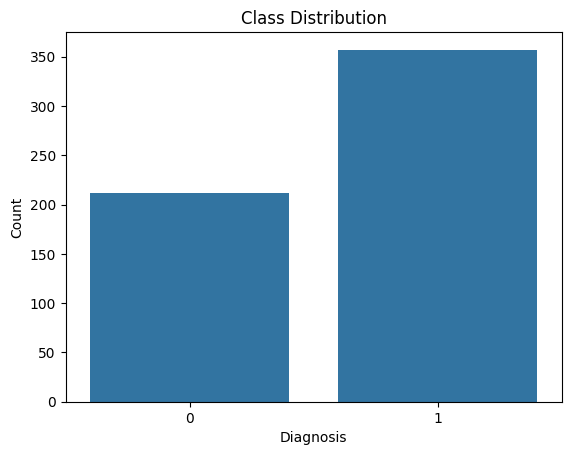

In [ ]:
sns.countplot(x=y)
plt.title("Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(455, 30)
(114, 30)


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

Scaling completed


In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = []

for name, model in models.items():

    # Train model
    model.fit(X_train_scaled, y_train)

    # Prediction
    y_pred = model.predict(X_test_scaled)

    # Probability prediction
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Store results
    results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc
    ])

# Create dataframe
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.982456,0.986111,0.986111,0.986111,0.995370
1,SVM,0.982456,0.986111,0.986111,0.986111,0.995040
2,KNN,0.956140,0.958904,0.972222,0.965517,0.978836
3,Decision Tree,0.912281,0.955882,0.902778,0.928571,0.915675
4,Random Forest,0.956140,0.958904,0.972222,0.965517,0.993882


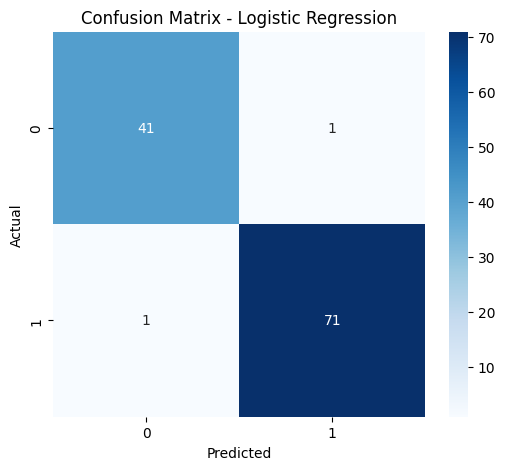

In [ ]:
best_model = LogisticRegression(max_iter=1000)

best_model.fit(X_train_scaled, y_train)

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

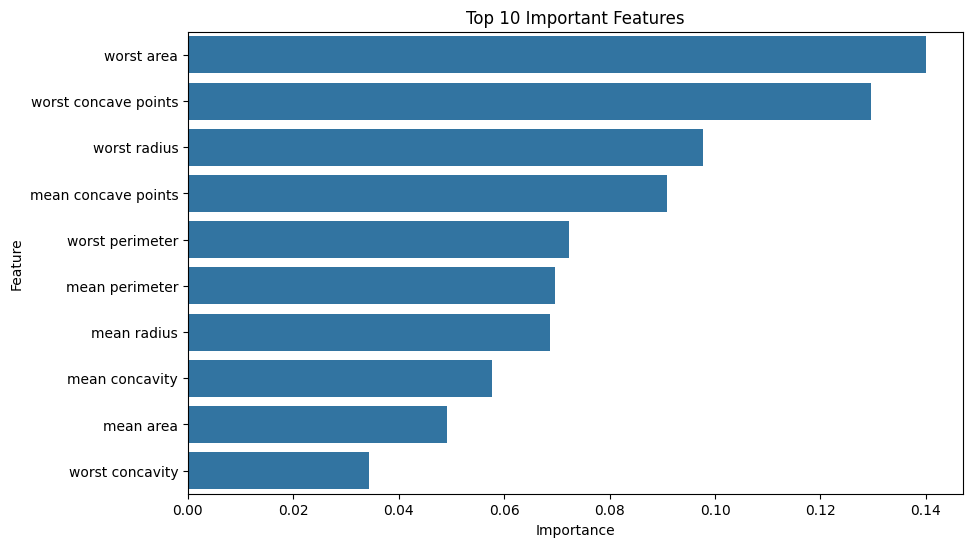

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title("Top 10 Important Features")

plt.show()

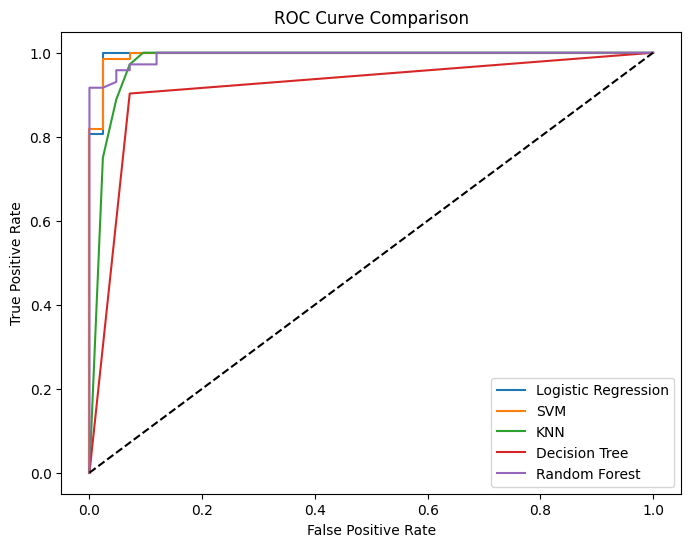

In [ ]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(8,6))

for name, model in models.items():

    model.fit(X_train_scaled, y_train)

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()

plt.show()

In [ ]:
results_df.to_csv("model_results.csv", index=False)

print("Results saved successfully")

Results saved successfully


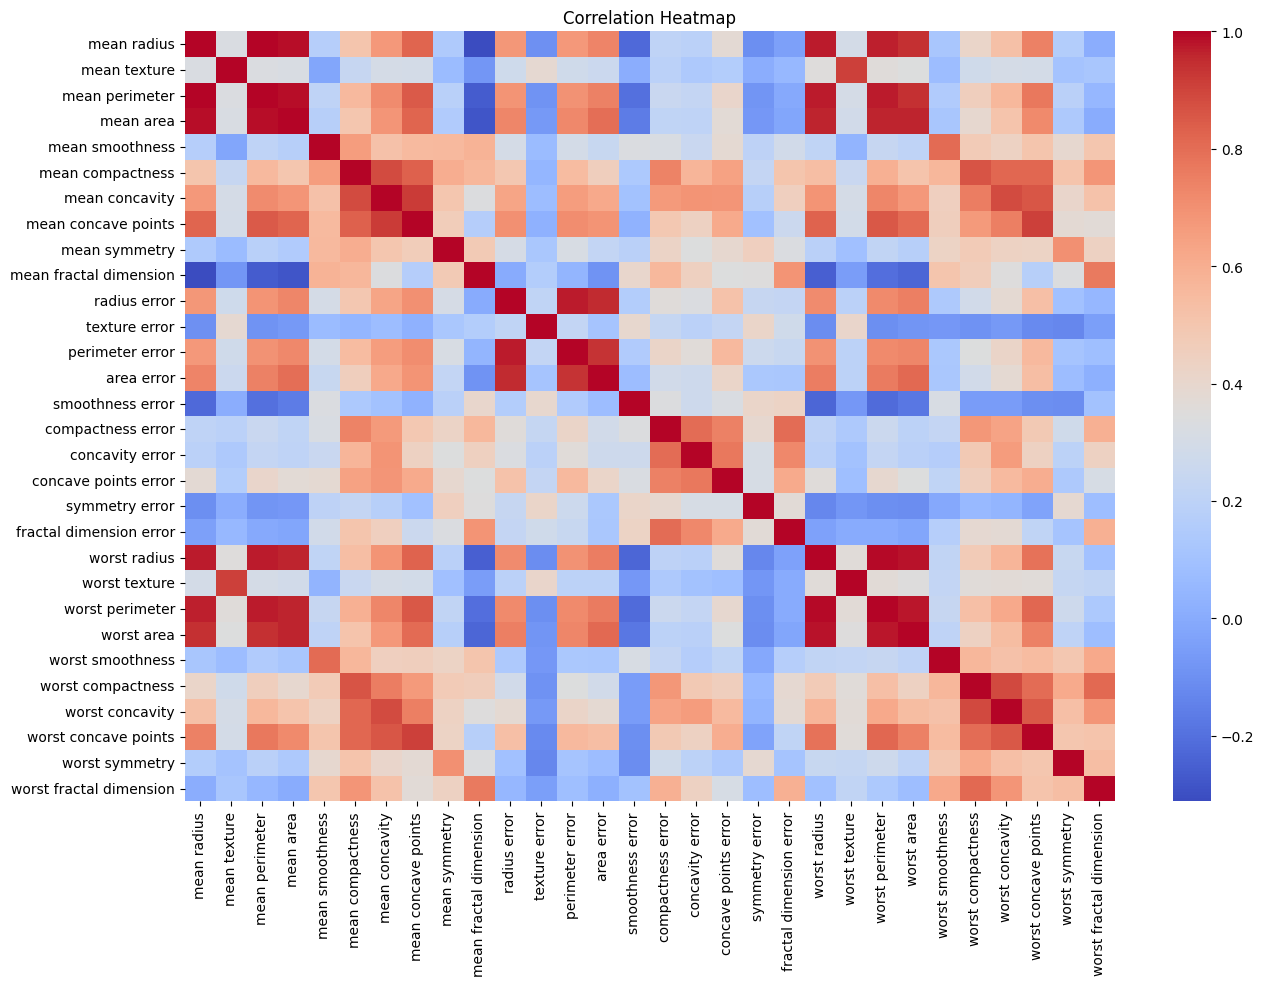

In [ ]:
plt.figure(figsize=(15,10))

correlation = X.corr()

sns.heatmap(correlation, cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()